# Logistic Regression from Scratch

Binary classification on the **Breast Cancer Wisconsin** dataset using a logistic regression model implemented from scratch with gradient descent (NumPy only), then evaluated with scikit-learn metrics.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

## Load Dataset

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

## Train / Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Feature Scaling

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Logistic Regression From Scratch

In [5]:
class LogisticRegressionScratch:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, y, y_pred):
        return -np.mean(
            y * np.log(y_pred + 1e-15) +
            (1 - y) * np.log(1 - y_pred + 1e-15)
        )

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):

            z = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(z)

            loss = self.compute_loss(y, y_pred)

            self.loss_history.append(loss)

            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            if epoch % 100 == 0:
                print(f"Epoch {epoch}: Loss = {loss:.4f}")

    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)

    def predict(self, X):
        probs = self.predict_proba(X)
        return (probs >= 0.5).astype(int)

## Training Loop Flow

The diagram below visualizes one epoch of gradient descent: forward pass (blue) → loss (orange) → gradients (red) → parameter update (green), repeating each epoch.

![Gradient Descent Training Loop](./images/gradient_descent_flow.png)

## Train Model

In [24]:
model = LogisticRegressionScratch(
    learning_rate=0.003,
    epochs=5000
)

model.fit(X_train, y_train)

Epoch 0: Loss = 0.6931
Epoch 100: Loss = 0.4050
Epoch 200: Loss = 0.3130
Epoch 300: Loss = 0.2659
Epoch 400: Loss = 0.2364
Epoch 500: Loss = 0.2158
Epoch 600: Loss = 0.2003
Epoch 700: Loss = 0.1882
Epoch 800: Loss = 0.1784
Epoch 900: Loss = 0.1703
Epoch 1000: Loss = 0.1635
Epoch 1100: Loss = 0.1576
Epoch 1200: Loss = 0.1525
Epoch 1300: Loss = 0.1480
Epoch 1400: Loss = 0.1439
Epoch 1500: Loss = 0.1403
Epoch 1600: Loss = 0.1371
Epoch 1700: Loss = 0.1342
Epoch 1800: Loss = 0.1315
Epoch 1900: Loss = 0.1290
Epoch 2000: Loss = 0.1267
Epoch 2100: Loss = 0.1246
Epoch 2200: Loss = 0.1226
Epoch 2300: Loss = 0.1208
Epoch 2400: Loss = 0.1191
Epoch 2500: Loss = 0.1175
Epoch 2600: Loss = 0.1160
Epoch 2700: Loss = 0.1146
Epoch 2800: Loss = 0.1132
Epoch 2900: Loss = 0.1119
Epoch 3000: Loss = 0.1107
Epoch 3100: Loss = 0.1096
Epoch 3200: Loss = 0.1085
Epoch 3300: Loss = 0.1074
Epoch 3400: Loss = 0.1064
Epoch 3500: Loss = 0.1055
Epoch 3600: Loss = 0.1046
Epoch 3700: Loss = 0.1037
Epoch 3800: Loss = 0.102

## Evaluation Metrics

In [27]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\n" + "=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")


print("\nClassification Report")
print(classification_report(y_test, y_pred))


MODEL EVALUATION
Accuracy  : 0.9912
Precision : 0.9861
Recall    : 1.0000
F1 Score  : 0.9930
ROC-AUC   : 0.9987

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        43
           1       0.99      1.00      0.99        71

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



## Confusion Matrix

In [20]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Negative : {tn}")
print(f"False Positive: {fp}")
print(f"False Negative: {fn}")
print(f"True Positive : {tp}")


Confusion Matrix
[[42  1]
 [ 0 71]]

True Negative : 42
False Positive: 1
False Negative: 0
True Positive : 71


## Loss Curve

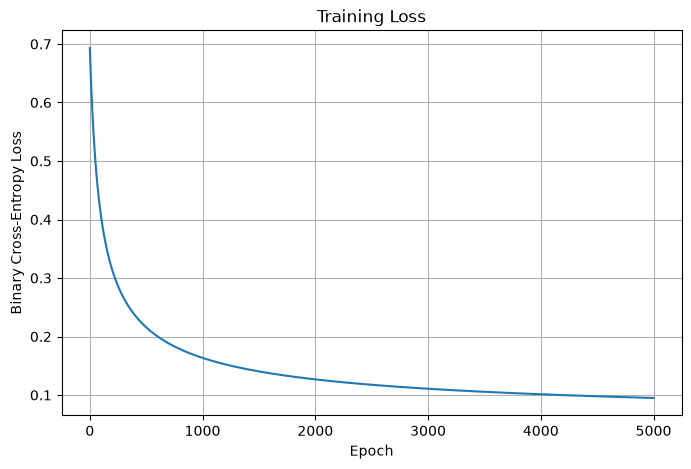

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(model.loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True)
plt.show()